# Import Libraries

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import seaborn as sns

# Konfigurasi Dataset

In [9]:
BS = 32
TS = (24, 24)

train_dir = "dataset/train"
test_dir = "dataset/test"

# Data Generator

In [10]:
train_gen = ImageDataGenerator(
    rescale=1./255
)

test_gen = ImageDataGenerator(
    rescale=1./255
)

train_batch = train_gen.flow_from_directory(
    train_dir,
    target_size=TS,
    color_mode='grayscale',
    batch_size=BS,
    class_mode='categorical',
    shuffle=True
)

valid_batch = test_gen.flow_from_directory(
    test_dir,
    target_size=TS,
    color_mode='grayscale',
    batch_size=BS,
    class_mode='categorical',
    shuffle=False
)

print("Jumlah kelas :", train_batch.num_classes)
print("Nama kelas :", train_batch.class_indices)

Found 2467 images belonging to 4 classes.
Found 433 images belonging to 4 classes.
Jumlah kelas : 4
Nama kelas : {'Closed': 0, 'Open': 1, 'no_yawn': 2, 'yawn': 3}


# Membangun Model CNN

In [12]:
cnn_model = Sequential([
    
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(24,24,1)
    ),
    
    MaxPooling2D((2,2)),
    
    Conv2D(
        32,
        (3,3),
        activation='relu'
    ),
    
    MaxPooling2D((2,2)),
    
    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),
    
    Dropout(0.25),

    Flatten(),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        4,
        activation='softmax'
    )
])

# Arsitektur Model CNN yang Dibangun

In [13]:
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 22, 22, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 11, 11, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 9, 9, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 2, 2, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,476 (240.14 KB)

 Trainable params: 61,476 (240.14 KB)

 Non-trainable params: 0 (0.00 B)

# Compile Model CNN

In [14]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Training Model CNN

In [15]:
history = cnn_model.fit(
    train_batch,
    validation_data=valid_batch,
    epochs=50
)

Epoch 1/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 52s 618ms/step - accuracy: 0.4957 - loss: 1.0206 - val_accuracy: 0.6998 - val_loss: 0.5993
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 11s 141ms/step - accuracy: 0.7219 - loss: 0.5611 - val_accuracy: 0.7229 - val_loss: 0.5047
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 11s 142ms/step - accuracy: 0.7499 - loss: 0.4973 - val_accuracy: 0.7829 - val_loss: 0.4278
Epoch 4/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 11s 142ms/step - accuracy: 0.7665 - loss: 0.4471 - val_accuracy: 0.7898 - val_loss: 0.3918
Epoch 5/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 11s 139ms/step - accuracy: 0.7844 - loss: 0.4162 - val_accuracy: 0.7898 - val_loss: 0.3882
Epoch 6/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 11s 145ms/step - accuracy: 0.7908 - loss: 0.3999 - val_accuracy: 0.8152 - val_loss: 0.3586
Epoch 7/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 11s 145ms/step - accuracy: 0.8135 - loss: 0.3632 - val_accuracy: 0.7898 - val_loss: 0.3529
Epoch 8/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 11s 143ms/step - accuracy: 0.8103 - loss: 0.3579 - val_accu

# Grafik Akurasi

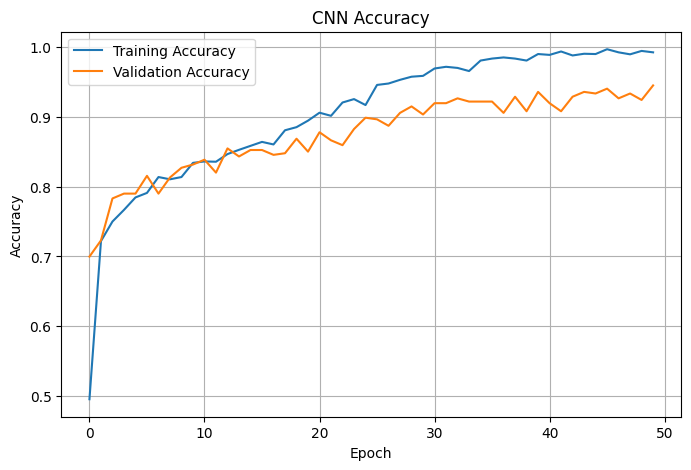

In [16]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy")
plt.legend()
plt.grid()

plt.show()

# Grafik Loss

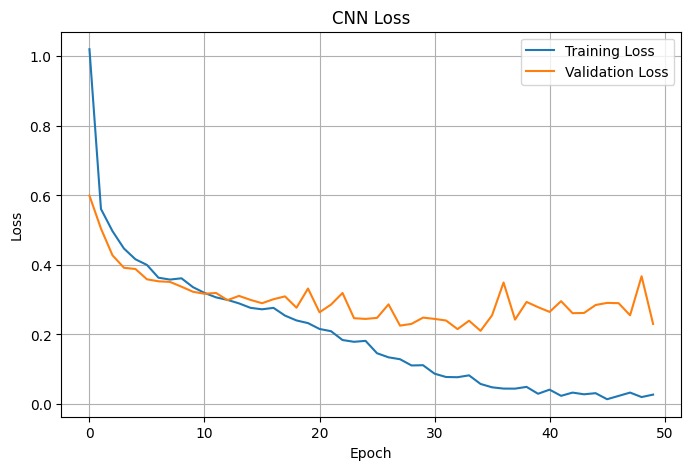

In [17]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss")
plt.legend()
plt.grid()

plt.show()

# Evaluasi Model

In [18]:
loss, accuracy = cnn_model.evaluate(valid_batch)

print("Loss     :", loss)
print("Accuracy :", accuracy)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.9446 - loss: 0.2303
Loss     : 0.23026056587696075
Accuracy : 0.9445727467536926


# Prediksi Dataset

In [19]:
valid_batch.reset()

pred = cnn_model.predict(valid_batch)

y_pred = np.argmax(pred, axis=1)
y_true = valid_batch.classes

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step


# Confusion Matrix

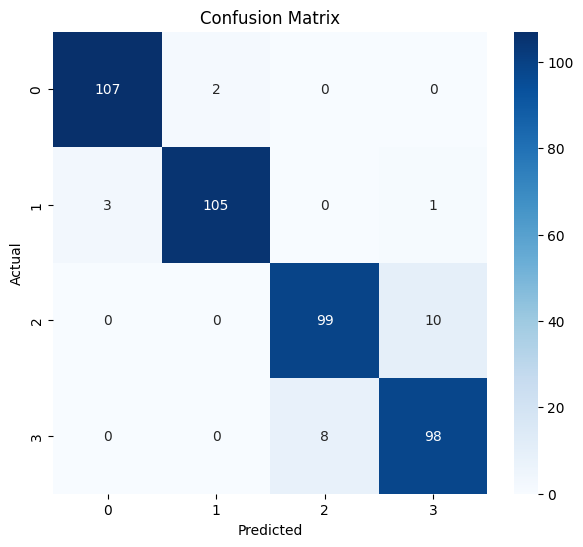

In [20]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# Classification Report

In [21]:
class_names = list(valid_batch.class_indices.keys())

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

      Closed       0.97      0.98      0.98       109
        Open       0.98      0.96      0.97       109
     no_yawn       0.93      0.91      0.92       109
        yawn       0.90      0.92      0.91       106

    accuracy                           0.94       433
   macro avg       0.94      0.94      0.94       433
weighted avg       0.94      0.94      0.94       433



# Visualisasi Prediksi

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


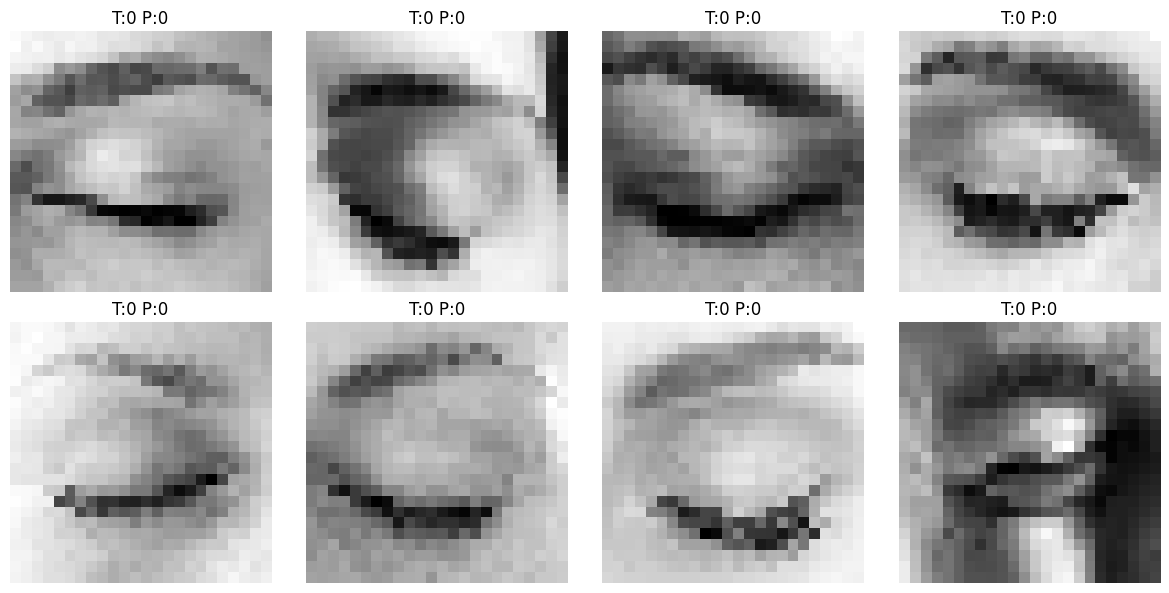

In [51]:
images, labels = next(valid_batch)

predictions = cnn_model.predict(images)

plt.figure(figsize=(12,6))

for i in range(8):

    plt.subplot(2,4,i+1)

    plt.imshow(
        images[i].reshape(24,24),
        cmap='gray'
    )

    true_label = np.argmax(labels[i])
    pred_label = np.argmax(predictions[i])

    plt.title(
        f"T:{true_label} P:{pred_label}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

# Simpan Model CNN

In [23]:
os.makedirs("models", exist_ok=True)

cnn_model.save(
    "models/cnn.h5"
)

print("Model berhasil disimpan")

Model berhasil disimpan
